# Global Renewable Energy: Animated Geospatial Visualization

A geospatial visualization project comparing renewable electricity production and renewable energy consumption across countries over time.

The notebook combines **GitHub-friendly static comparisons** with **animated Plotly choropleths** so the analysis remains visually reviewable even when interactive notebook output is not rendered.

**Tools:** Python · Pandas · Matplotlib · Plotly

## 1. Load renewable electricity production data

The analysis expects a local file at `data/renewable_production.csv`.

In [ ]:
import pandas as pd
import plotly.express as px

production = pd.read_csv("data/renewable_production.csv")
production.head()


,Country,Code,Year,Renewable electricity (% electricity production)
0,Afghanistan,AFG,1990,67.730496
1,Afghanistan,AFG,1991,67.980296
2,Afghanistan,AFG,1992,67.994310
3,Afghanistan,AFG,1993,68.345324
4,Afghanistan,AFG,1994,68.704512


## 2. Prepare the production timeline

Sorting by year ensures the animation progresses chronologically. The available production records are filtered to the 2008–2016 analysis window.

In [ ]:
production = production.sort_values("Year")

production_period = production.loc[
    production["Year"].between(2008, 2016)
].copy()

production_period.head()


,Country,Code,Year,Renewable electricity (% electricity production)
700,Bulgaria,BGR,1990,4.456468
2493,Kenya,KEN,1990,92.859351
50,Algeria,DZA,1990,0.838301
2749,Libya,LBY,1990,0.000000
4526,South Korea,KOR,1990,6.037714


## 3. Static comparison: countries with the highest renewable electricity share

Before moving into the animated map, a ranked bar chart provides a GitHub-friendly snapshot of the latest production year available in the dataset.

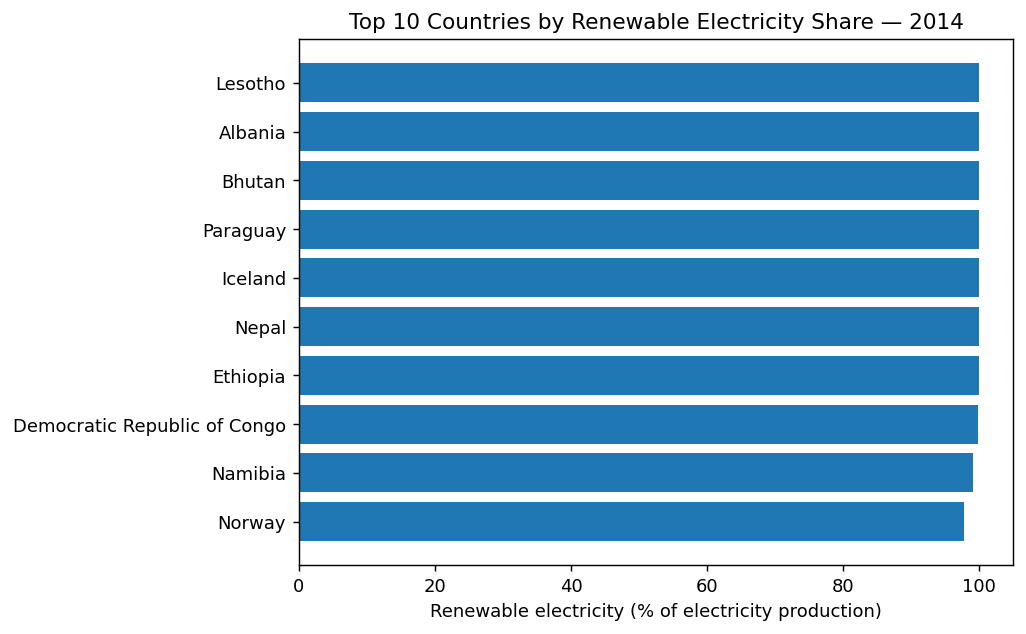

In [ ]:
latest_production_year = production_period["Year"].max()

production_top10 = (
    production_period.loc[
        production_period["Year"].eq(latest_production_year)
        & production_period["Code"].astype(str).str.len().eq(3)
    ]
    .nlargest(10, "Renewable electricity (% electricity production)")
    .sort_values("Renewable electricity (% electricity production)")
)

ax = production_top10.plot(
    kind="barh",
    x="Country",
    y="Renewable electricity (% electricity production)",
    legend=False,
    figsize=(8, 5),
)

ax.set_title(
    f"Top 10 Countries by Renewable Electricity Share — {latest_production_year}"
)
ax.set_xlabel("Renewable electricity (% of electricity production)")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

In **2014**, several countries in the dataset generated nearly all of their electricity from renewable sources. This ranking focuses on **share of electricity production**, so it highlights renewable intensity rather than the absolute amount of energy produced.

## 4. Animated map: renewable share of electricity production

The Plotly choropleth adds geographic context and an animation control for exploring how country-level renewable electricity shares change over time.

> **GitHub note:** interactive Plotly output may not render in every notebook preview. The static chart above is included so the project remains visually reviewable on GitHub.

In [ ]:
fig = px.choropleth(
    production_period,
    locations="Code",
    color="Renewable electricity (% electricity production)",
    hover_name="Country",
    animation_frame="Year",
    color_continuous_scale="Viridis",
    title="Renewable Electricity Production by Country, 2008–2016",
)

fig.update_geos(projection_type="natural earth")
fig.show()


## 5. Load and reshape renewable energy consumption data

The consumption file is stored in wide format. Melting converts energy-source columns into tidy rows that are easier to filter and visualize.

In [ ]:
consumption = pd.read_csv("data/renewable_consumption.csv")

consumption_long = consumption.melt(
    id_vars=["Country", "Code", "Year"],
    var_name="Energy Source",
    value_name="Renewable Energy Consumption",
)

consumption_long = consumption_long.sort_values("Year")
consumption_long.head()


,Country,Code,Year,Energy Source,Renewable Energy Consumption
0,Algeria,DZA,1965,Traditional biofuels,NaN
1,Algeria,DZA,1966,Traditional biofuels,NaN
2,Algeria,DZA,1967,Traditional biofuels,NaN
3,Algeria,DZA,1968,Traditional biofuels,NaN
4,Algeria,DZA,1969,Traditional biofuels,NaN


## 6. Focus on total renewable energy consumption

The analysis selects the `Total` series and the same 2008–2016 time window for the country-level consumption view.

In [ ]:
total_consumption = consumption_long.loc[
    consumption_long["Year"].between(2008, 2016)
    & consumption_long["Energy Source"].eq("Total")
].copy()

total_consumption.head()


## 7. Static comparison: countries with the highest total renewable energy consumption

A second ranked view complements the production-share chart. Here the metric is total renewable energy consumption, so large energy-consuming economies naturally become more prominent.

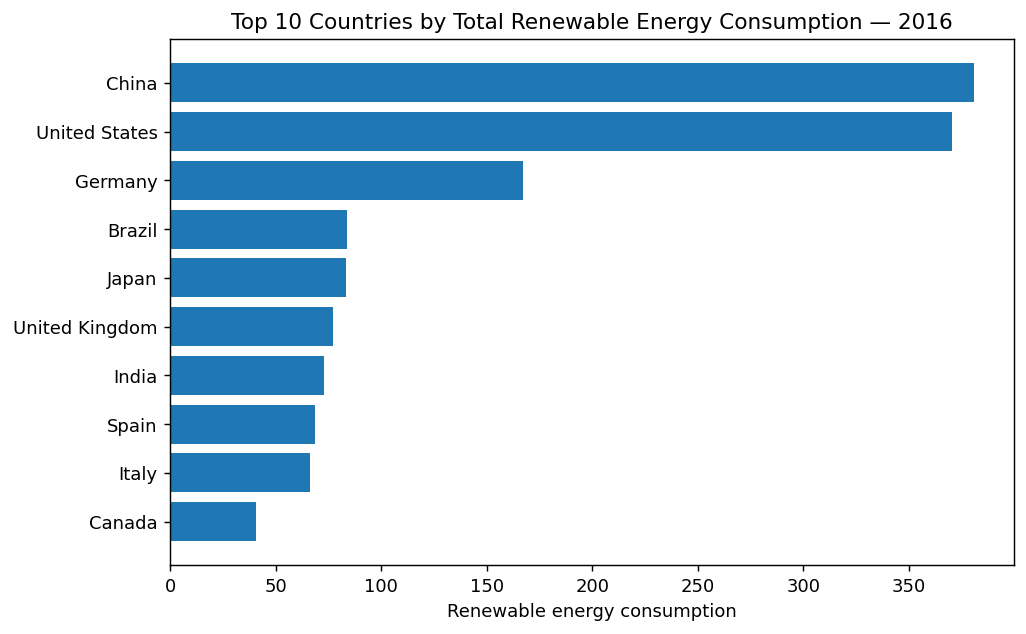

In [ ]:
latest_consumption_year = total_consumption["Year"].max()

consumption_top10 = (
    total_consumption.loc[
        total_consumption["Year"].eq(latest_consumption_year)
        & total_consumption["Code"].astype(str).str.len().eq(3)
    ]
    .nlargest(10, "Renewable Energy Consumption")
    .sort_values("Renewable Energy Consumption")
)

ax = consumption_top10.plot(
    kind="barh",
    x="Country",
    y="Renewable Energy Consumption",
    legend=False,
    figsize=(8, 5),
)

ax.set_title(
    f"Top 10 Countries by Total Renewable Energy Consumption — {latest_consumption_year}"
)
ax.set_xlabel("Renewable energy consumption")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

In **2016**, China and the United States are the two largest values in this dataset's total renewable-energy-consumption measure. This ranking should not be confused with renewable **share**: a country can consume a large absolute amount of renewable energy without having the highest renewable percentage.

## 8. Animated map: total renewable energy consumption

The animated choropleth shows the geographic distribution of total renewable energy consumption through time.

In [ ]:
fig = px.choropleth(
    total_consumption,
    locations="Code",
    locationmode="ISO-3",
    color="Renewable Energy Consumption",
    hover_name="Country",
    animation_frame="Year",
    color_continuous_scale="Viridis",
    title="Total Renewable Energy Consumption by Country, 2008–2016",
)

fig.update_geos(projection_type="natural earth")
fig.show()


## 9. Key takeaways

- Static ranked charts and animated choropleths answer complementary questions: rankings emphasize magnitude, while maps emphasize geographic pattern.
- Renewable **electricity share** and total renewable **energy consumption** are different metrics and should not be compared as if they used the same scale.
- Reshaping the consumption dataset from wide to long format makes it easier to filter, group, and animate in Plotly.
- Including static previews makes the analysis readable in GitHub even when interactive Plotly output is unavailable.
- ISO-3 country codes provide a consistent geographic key for country-level choropleth mapping.